# Biggest Polities: Direct HYDE × Cliopatria Computation

Overlay Cliopatria polity polygons directly on the HYDE 3.4 population grid
to compute population under each polity at each time step. No sampling needed.

For each HYDE time step (127 steps from 10,000 BCE to 2024 CE):
1. Find all Cliopatria polities active at that year
2. Rasterize each polygon onto the HYDE 2160×4320 grid
3. Sum population within each polygon

This gives population under each polity at each time step, from which we can
compute total person-years, total births, and population-over-time graphs.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import h5py
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds
from shapely.geometry import mapping
from tqdm import tqdm
import matplotlib.pyplot as plt

## 1. Load data

In [2]:
# Load HYDE population grid
ds = xr.open_dataset('../Raw_Data/HYDE34/NetCDF/population.nc', decode_times=False)
pop_all = ds['population']  # shape (127, 2160, 4320)
lats = pop_all.coords['lat'].values
lons = pop_all.coords['lon'].values

# Convert time to years (same formula as person.py)
hyde_years = (ds['time'].values // 365).astype(int) + 1
print(f'HYDE: {len(hyde_years)} time steps, {hyde_years[0]} to {hyde_years[-1]}')
print(f'Grid: {pop_all.shape[1]}×{pop_all.shape[2]}')

# Load births grid (128 steps; first 127 align with population years)
with h5py.File('../Processed_Data/births_array.h5', 'r') as f:
    births_all = f['data'][:127]  # only take the 127 aligned with population
print(f'Births: {births_all.shape}')

# Rasterization transform (HYDE grid bounds)
TRANSFORM = from_bounds(
    lons.min() - 0.0833/2, lats.min() - 0.0833/2,
    lons.max() + 0.0833/2, lats.max() + 0.0833/2,
    4320, 2160
)

# Load Cliopatria (polities only, no containers)
clio_raw = gpd.read_file('cliopatria_polities_only.geojson')
clio = clio_raw[~clio_raw['Name'].str.startswith('(')].copy()
print(f'Cliopatria: {len(clio):,} polity records, {clio["Name"].nunique()} unique names')

HYDE: 127 time steps, -10000 to 2024
Grid: 2160×4320
Births: (127, 2160, 4320)


/opt/anaconda3/lib/python3.11/site-packages/pyogrio/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Cliopatria: 12,987 polity records, 1522 unique names


/opt/anaconda3/lib/python3.11/site-packages/geopandas/array.py:348: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  self.crs = crs
/opt/anaconda3/lib/python3.11/site-packages/geopandas/geodataframe.py:464: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  level.crs = crs


## 2. Compute annual population and births for each Cliopatria polity

For each Cliopatria record (polygon with FromYear–ToYear):
1. Rasterize the polygon onto the HYDE grid (once per record)
2. At each HYDE time step within [FromYear, ToYear], sum population and births within the mask
3. Log-linear interpolate between HYDE steps to get annual values
4. When multiple records exist for the same polity name (different time periods or boundary changes), stitch them together

This gives an annual time series of population and births for every polity.

In [3]:
# For each Cliopatria record: rasterize polygon, sum HYDE population AND births at
# relevant time steps, then log-linear interpolate to get annual values.

# Preload all HYDE grids into memory (keyed by year index for fast lookup)
print('Loading all HYDE grids...')
pop_grids = {}
birth_grids = {}
hyde_year_to_idx = {}
for ti, year in enumerate(hyde_years):
    pop_grids[year] = pop_all.isel(time=ti).values
    birth_grids[year] = births_all[ti]
    hyde_year_to_idx[year] = ti

# World totals at each HYDE step
world_pop_hyde = {year: np.nansum(grid) for year, grid in pop_grids.items()}
world_births_hyde = {year: np.nansum(grid) for year, grid in birth_grids.items()}

def log_interp(hyde_yrs, hyde_vals, from_year, to_year):
    """Log-linear interpolate HYDE values to annual series for [from_year, to_year]."""
    hyde_vals_safe = np.where(hyde_vals > 0, hyde_vals, 1.0)
    all_zero = hyde_vals <= 0
    log_vals = np.log(hyde_vals_safe)
    
    annual = {}
    for year in range(from_year, to_year + 1):
        if year in dict(zip(hyde_yrs, hyde_vals)):
            annual[year] = dict(zip(hyde_yrs, hyde_vals))[year]
        elif year < hyde_yrs[0] or year > hyde_yrs[-1]:
            continue
        else:
            idx = np.searchsorted(hyde_yrs, year, side='right') - 1
            y0, y1 = hyde_yrs[idx], hyde_yrs[idx + 1]
            t = (year - y0) / (y1 - y0)
            if all_zero[idx] and all_zero[idx + 1]:
                annual[year] = 0.0
            else:
                annual[year] = np.exp(log_vals[idx] * (1 - t) + log_vals[idx + 1] * t)
    return annual

# Process each Cliopatria record
print(f'Processing {len(clio):,} Cliopatria records...')
record_results = []  # (Name, year, population, births)

all_hyde_sorted = sorted(hyde_years)

for _, row in tqdm(clio.iterrows(), total=len(clio), desc='Rasterizing'):
    name = row['Name']
    from_year = int(row['FromYear'])
    to_year = int(row['ToYear'])
    
    # Rasterize this polygon once
    try:
        mask = geometry_mask([mapping(row.geometry)], out_shape=(2160, 4320),
                            transform=TRANSFORM, invert=True)
    except Exception:
        continue
    
    if not mask.any():
        continue
    
    # Find HYDE years within this record's active range + bracketing years for interpolation
    active_hyde = [y for y in hyde_years if from_year <= y <= to_year]
    idx_before = np.searchsorted(all_hyde_sorted, from_year) - 1
    idx_after = np.searchsorted(all_hyde_sorted, to_year, side='right')
    if idx_before >= 0:
        active_hyde = [all_hyde_sorted[idx_before]] + active_hyde
    if idx_after < len(all_hyde_sorted):
        active_hyde = active_hyde + [all_hyde_sorted[idx_after]]
    active_hyde = sorted(set(active_hyde))
    
    if len(active_hyde) == 0:
        continue
    
    # Sum population and births within mask at each HYDE year
    hyde_pops = np.array([np.nansum(pop_grids[y][mask]) for y in active_hyde])
    hyde_births = np.array([np.nansum(birth_grids[y][mask]) for y in active_hyde])
    active_hyde = np.array(active_hyde)
    
    # Log-linear interpolate to every year in [from_year, to_year]
    pop_annual = log_interp(active_hyde, hyde_pops, from_year, to_year)
    births_annual = log_interp(active_hyde, hyde_births, from_year, to_year)
    
    for year in range(from_year, to_year + 1):
        pop = pop_annual.get(year)
        births = births_annual.get(year)
        if pop is not None:
            record_results.append((name, year, pop, births or 0.0))

print(f'{len(record_results):,} annual polity-year records')

# Build DataFrame
df_annual = pd.DataFrame(record_results, columns=['polity', 'year', 'population', 'births'])
print(f'{df_annual["polity"].nunique()} polities')

# World annual series (log-linear interpolated)
world_pop_annual = log_interp(
    np.array(sorted(world_pop_hyde.keys())),
    np.array([world_pop_hyde[y] for y in sorted(world_pop_hyde.keys())]),
    int(hyde_years[0]), int(hyde_years[-1])
)
world_births_annual = log_interp(
    np.array(sorted(world_births_hyde.keys())),
    np.array([world_births_hyde[y] for y in sorted(world_births_hyde.keys())]),
    int(hyde_years[0]), int(hyde_years[-1])
)

Loading all HYDE grids...
Processing 12,987 Cliopatria records...


Rasterizing: 100%|████████████████████████| 12987/12987 [03:43<00:00, 58.00it/s]


239,063 annual polity-year records
1522 polities


## 3. Rankings: total person-years and total births by polity

In [4]:
# Person-years = sum of annual population; total births = sum of annual births
polity_py = df_annual.groupby('polity')['population'].sum().sort_values(ascending=False)
polity_births = df_annual.groupby('polity')['births'].sum().sort_values(ascending=False)

world_py = sum(world_pop_annual.values())
world_births = sum(world_births_annual.values())

from math import log10, floor
def sig2(x):
    if x == 0: return '0'
    d = -floor(log10(abs(x))) + 1
    r = round(x, d)
    if d <= 0: return f'{int(r):,}'
    return f'{r:,.{d}f}'

print(f'Total person-years (world): {world_py/1e9:.0f} billion')
print(f'Total births (world): {world_births/1e9:.1f} billion')

# Rank by person-years, show both
print(f'\n{"Rank":<5} {"Polity":<50} {"Pers-yrs (B)":>12} {"Births (M)":>10}')
print('-' * 80)
for i, (name, py) in enumerate(polity_py.head(50).items(), 1):
    births = polity_births.get(name, 0)
    print(f'{i:<5} {name:<50} {sig2(py/1e9):>12} {sig2(births/1e6):>10}')

Total person-years (world): 1689 billion
Total births (world): 62.4 billion

Rank  Polity                                             Pers-yrs (B) Births (M)
--------------------------------------------------------------------------------
1     People's Republic of China                                   78      1,600
2     Qing Dynasty                                                 65      2,500
3     Republic of India                                            64      1,800
4     British Raj                                                  30      1,300
5     United States of America                                     29        600
6     Mughal Empire                                                23        960
7     Ming Dynasty                                                 22        890
8     Roman Empire                                                 16        680
9     Union of Soviet Socialist Republics                          16        410
10    Han Dynasty               

## 4. Population over time: top 10 polities

NameError: name 'world_annual' is not defined

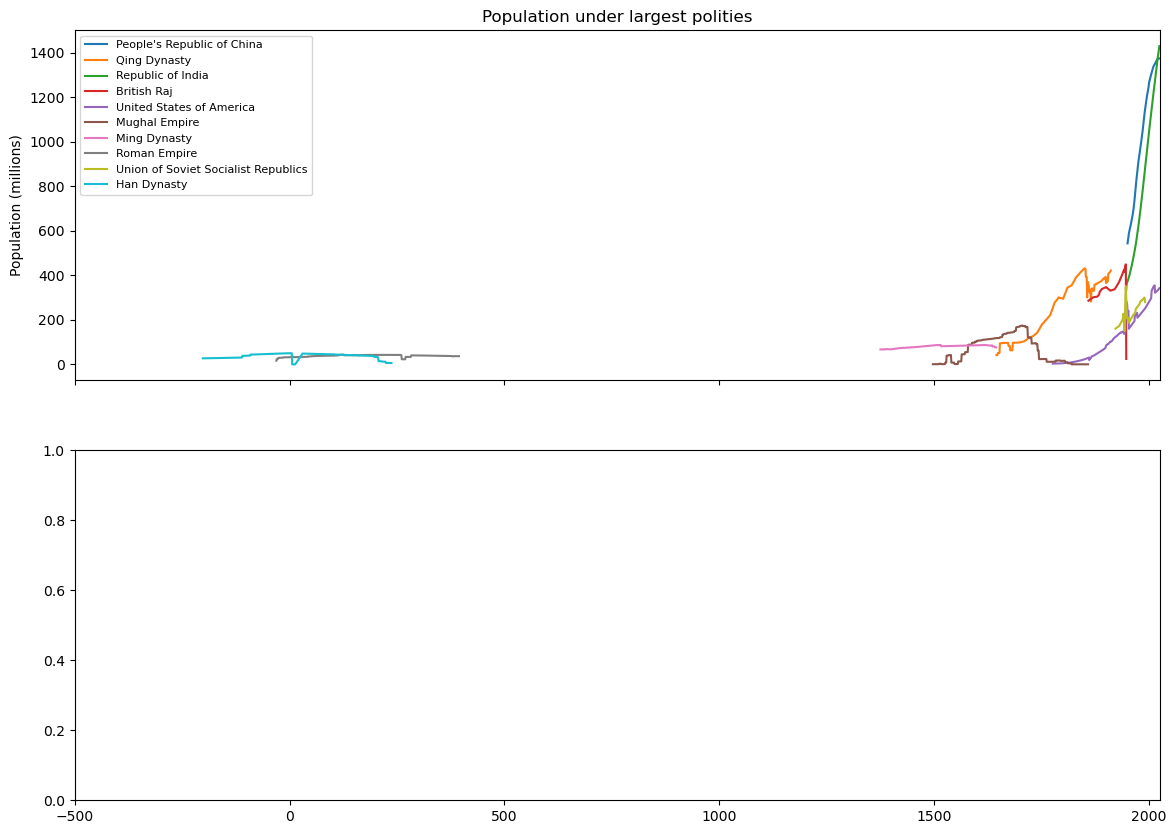

In [5]:
# Get top 10 polities by person-years
top10 = list(polity_py.head(10).index)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for polity in top10:
    pdata = df_annual[df_annual['polity'] == polity].set_index('year')['population'].sort_index()
    ax1.plot(pdata.index, pdata.values / 1e6, label=polity, linewidth=1.5)

ax1.set_ylabel('Population (millions)')
ax1.set_title('Population under largest polities')
ax1.legend(fontsize=8, loc='upper left')
ax1.set_xlim(-500, 2025)

# Share of world population
world_series = pd.Series(world_annual).sort_index()

for polity in top10:
    pdata = df_annual[df_annual['polity'] == polity].set_index('year')['population'].sort_index()
    # Align with world series
    common_years = pdata.index.intersection(world_series.index)
    share = 100 * pdata.loc[common_years] / world_series.loc[common_years]
    ax2.plot(share.index, share.values, label=polity, linewidth=1.5)

ax2.set_ylabel('Share of world population (%)')
ax2.set_xlabel('Year')
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xlim(-500, 2025)

plt.tight_layout()
plt.show()